In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt #graphique
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier #K-NN classifier
from sklearn.datasets import load_digits #database number
from sklearn.metrics import confusion_matrix #aficher matric pour comparer une resultat

In [31]:
#charger dataset
digits=load_digits()
x,y=digits.data, digits.target #enter 0 et 9

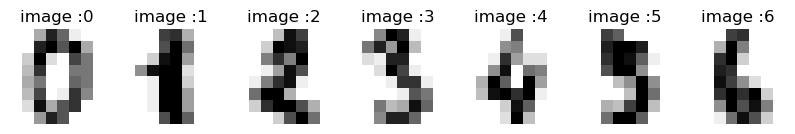

In [33]:
#visualiser image 4 targe10
_,axes =plt.subplots(nrows=1,ncols=7,figsize=(10,10))
for ax,image,label in zip(axes, digits.images,digits.target):
    ax.set_axis_off()
    ax.imshow(image,cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title('image :%i' %label)

In [35]:
#diviser
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [37]:
#creer le model Knn
knn=KNeighborsClassifier(n_neighbors=5)# nombre de voisin 5
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [39]:
#le taux de precision et voire le taux de performence
score=knn.score(x_test,y_test)
print('score: %f' %score)


score: 0.988889


In [52]:
# Initialisation des tableaux pour stocker les précisions
neighbors = np.arange(1, 21)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

In [59]:
# Boucle pour tester les valeurs de k de 1 à 20
for i, k in enumerate(neighbors):
    # Créer et entraîner le modèle K-NN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)  
    # Calculer la précision sur les données d'entraînement et de test
    train_accuracy[i] = knn.score(x_train, y_train)
    test_accuracy[i] = knn.score(x_test, y_test)

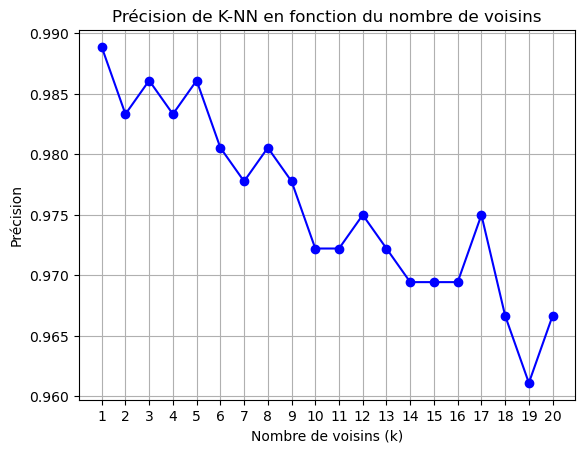

In [61]:
#visualisaiion taux de precision (test)
plt.plot(range(1, 21), test_accuracy, "o-", color='blue')  # 'o-' pour les points connectés par des lignes
plt.title('Précision de K-NN en fonction du nombre de voisins')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision')
plt.xticks(range(1, 21))  # Afficher les valeurs de k de 1 à 20
plt.grid(True)
plt.show()

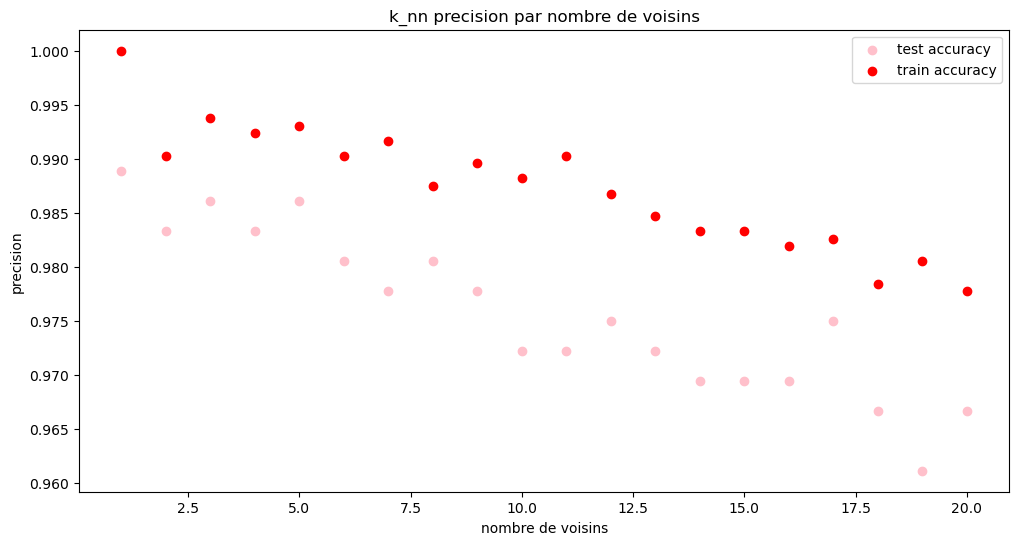

In [63]:
plt.figure(figsize=(12,6))
plt.title('k_nn precision par nombre de voisins')
plt.scatter(neighbors,test_accuracy,label='test accuracy',color='pink')
plt.scatter(neighbors, train_accuracy, label='train accuracy', color='red')
plt.legend()
plt.xlabel('nombre de voisins')
plt.ylabel('precision')
plt.show()

In [65]:
y_pred=knn.predict(x_test)


In [67]:
#matrice de confusion
cm=confusion_matrix(y_test,y_pred)
cm

array([[45,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 37,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, 27,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 38,  0,  0,  0,  1,  1,  0],
       [ 0,  0,  0,  0, 36,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 23,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 44,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 33,  0,  0],
       [ 0,  5,  1,  2,  0,  0,  0,  0, 30,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 35]], dtype=int64)

In [69]:
np.bincount(y_test)

array([45, 37, 28, 40, 36, 23, 45, 33, 38, 35], dtype=int64)

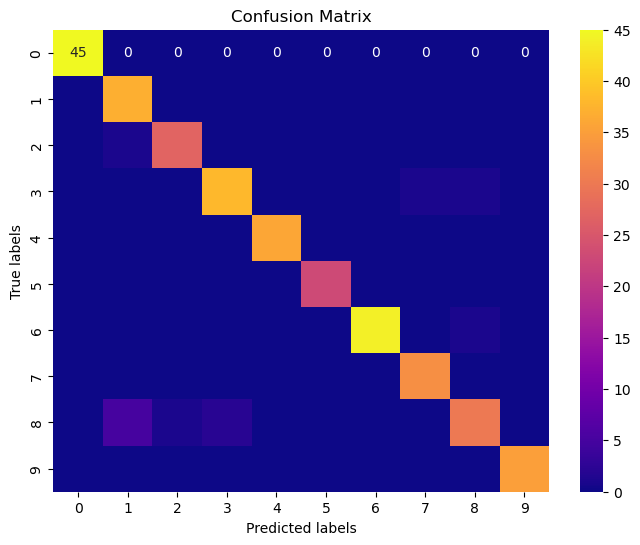

In [91]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='plasma', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [73]:
score = knn.score(x_test, y_test)  # Taux de précision sur les données de test
print("Taux de précision:", score)


Taux de précision: 0.9666666666666667


Le taux de précision de 0.967 (ou 96.67%) signifie que le modèle K-NN a fait des prédictions correctes dans environ 96.67% des cas pour les données de test.